In [32]:
%matplotlib inline
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from numba import jit
import os
from tqdm import tqdm
from scipy.spatial import Delaunay

## 2D Hard-Disk System and the KTHNY Phase Transition

### Model

N identical disks of diameter $\sigma$ in a square box of side $L$ with periodic boundary conditions.  The interaction is purely hard-core:

$$U(r_{ij}) = \begin{cases} \infty & r_{ij} < \sigma \\ 0 & r_{ij} \geq \sigma \end{cases}$$

The system is athermal — temperature only sets the energy scale and drops out.  The **packing fraction** $\eta = N\pi\sigma^2/(4L^2)$ is the sole control parameter.

### KTHNY theory vs. hard-disk reality

**KTHNY theory** (Kosterlitz, Thouless, Halperin, Nelson, Young) predicts that 2D melting proceeds via two *continuous* BKT-type transitions:

| Transition | Predicted type | Mechanism |
|---|---|---|
| Solid → Hexatic | Continuous (BKT) | Dislocation-pair unbinding |
| Hexatic → Liquid | Continuous (BKT) | Disclination unbinding |

**Hard disks do not fully follow this.** Large-scale simulations (Bernard & Krauth 2011 PRL; Kapfer & Krauth 2015 PRL) found:

| Transition | Actual type | $\eta$ boundaries ($N\to\infty$) |
|---|---|---|
| Solid → Hexatic | **Continuous** (KTHNY) ✓ | $\eta_m \approx 0.720$ |
| Hexatic → Liquid | **First-order** ✗ KTHNY | Coexistence: $\eta \in [0.700,\, 0.716]$ |

The hexatic–liquid transition is weakly **first-order** in hard disks, producing a narrow coexistence window where hexatic and liquid domains coexist. The solid–hexatic transition remains the continuous KTHNY transition.

### Complete phase diagram (hard disks, $N\to\infty$)

```
η < 0.700             Pure liquid
0.700 < η < 0.716     Hexatic + liquid coexistence   ← first-order
0.716 < η < 0.720     Pure hexatic
η > 0.720             Solid  (via continuous KTHNY transition)
```

### Three phases and their order

| Phase | Positional order | Bond-orientational order |
|---|---|---|
| **Solid** | Quasi-long-range ($g(r)\sim r^{-\eta_T}$) | Long-range ($\Psi_6\to$ const) |
| **Hexatic** | Short-range ($g(r)\sim e^{-r/\xi}$) | Quasi-long-range ($g_6(r)\sim r^{-\eta_6}$, $\eta_6\leq\tfrac{1}{4}$) |
| **Liquid** | Short-range | Short-range ($g_6(r)\sim e^{-r/\xi_6}$) |

### Signatures of the first-order hexatic–liquid transition

1. **Bimodal $|\Psi_6|$ histogram** inside the coexistence window (two peaks: liquid at $|\Psi_6|\approx 0$, hexatic at $|\Psi_6|>0$).
2. **Latent heat / pressure discontinuity** at fixed $\eta$ across the transition.
3. **Phase-separated snapshots**: liquid droplets embedded in a hexatic background (or vice versa).

### Monte Carlo algorithm

**Metropolis for hard disks** reduces to a pure accept/reject rule:
1. Pick a random particle $i$.
2. Propose displacement $(\Delta x,\Delta y)$ uniform in $[-\delta, \delta]^2$.
3. If the new position overlaps any other disk: **reject**.
4. Otherwise: **accept** unconditionally (energy change is always zero).

Overlap detection uses a **cell list** so that only particles in the $3\times 3$ neighbourhood of the new cell need to be checked — O(1) average cost per trial.

### Order parameter: $\psi_6$

$$\psi_6(j) = \frac{1}{n_j}\sum_{k\in\mathrm{Voronoi\,nbrs}(j)} e^{6i\theta_{jk}}$$

The **bond-orientational correlation function** $g_6(r) = \langle\mathrm{Re}[\psi_6^*(0)\,\psi_6(r)]\rangle$ distinguishes all three phases:
- Solid: constant (long-range order)
- Hexatic: algebraic $r^{-\eta_6}$ with $\eta_6 \leq 1/4$ (quasi-LRO)
- Liquid: exponential decay


In [33]:
#----------------------------------------------------------------------
##  CORE MONTE CARLO FUNCTIONS  (numba JIT)
#----------------------------------------------------------------------

@jit(nopython=True)
def mc_sweep(pos, L, sigma, delta, n_cells, max_per_cell):
    '''
    One full MC sweep: N single-particle Metropolis trial moves.

    Hard-disk Metropolis is an accept/reject rule only:
      - Propose displacement uniform in [-delta, delta]^2.
      - Accept if new position has no overlap with any other disk.
      - Reject otherwise.

    Overlap detection uses a cell list (fixed-size occupancy arrays).
    The cell list is built once at the start of the sweep and updated
    after each accepted move, so it remains exact throughout.

    Parameters
    ----------
    pos          : (N, 2) float64 array of positions in [0, L)
    L            : box side length
    sigma        : hard-disk diameter
    delta        : maximum displacement per axis
    n_cells      : number of cells per axis  (cell_size = L/n_cells >= sigma)
    max_per_cell : maximum particles per cell (set generously, e.g. 12)

    Returns
    -------
    pos          : updated positions
    n_accepted   : number of accepted moves this sweep
    '''
    N          = len(pos)
    cell_size  = L / n_cells
    sigma2     = sigma * sigma
    half_L     = 0.5 * L

    # ---- Build cell list ----
    # cell_count[cx, cy]       : particles currently in that cell
    # cell_occ[cx, cy, k]      : k-th particle index in that cell
    cell_count = np.zeros((n_cells, n_cells), dtype=np.int64)
    cell_occ   = np.full((n_cells, n_cells, max_per_cell), -1, dtype=np.int64)

    for i in range(N):
        cx = int(pos[i, 0] / cell_size) % n_cells
        cy = int(pos[i, 1] / cell_size) % n_cells
        cell_occ[cx, cy, cell_count[cx, cy]] = i
        cell_count[cx, cy] += 1

    n_accepted = 0

    for _ in range(N):
        i     = np.random.randint(0, N)
        old_x = pos[i, 0]
        old_y = pos[i, 1]
        new_x = (old_x + np.random.uniform(-delta, delta)) % L
        new_y = (old_y + np.random.uniform(-delta, delta)) % L

        # ---- Overlap check in 3x3 cell neighbourhood ----
        cx_new  = int(new_x / cell_size) % n_cells
        cy_new  = int(new_y / cell_size) % n_cells
        overlap = False

        for dcx in range(-1, 2):
            if overlap:
                break
            for dcy in range(-1, 2):
                if overlap:
                    break
                ncx = (cx_new + dcx) % n_cells
                ncy = (cy_new + dcy) % n_cells
                for k in range(cell_count[ncx, ncy]):
                    j = cell_occ[ncx, ncy, k]
                    if j == i:
                        continue
                    dx = new_x - pos[j, 0]
                    dy = new_y - pos[j, 1]
                    # Minimum image convention
                    if   dx >  half_L: dx -= L
                    elif dx < -half_L: dx += L
                    if   dy >  half_L: dy -= L
                    elif dy < -half_L: dy += L
                    if dx * dx + dy * dy < sigma2:
                        overlap = True
                        break

        if not overlap:
            # ---- Update cell list ----
            cx_old = int(old_x / cell_size) % n_cells
            cy_old = int(old_y / cell_size) % n_cells

            if cx_old != cx_new or cy_old != cy_new:
                # Remove i from old cell (swap with last entry)
                for k in range(cell_count[cx_old, cy_old]):
                    if cell_occ[cx_old, cy_old, k] == i:
                        last = cell_count[cx_old, cy_old] - 1
                        cell_occ[cx_old, cy_old, k]    = cell_occ[cx_old, cy_old, last]
                        cell_occ[cx_old, cy_old, last] = -1
                        cell_count[cx_old, cy_old]    -= 1
                        break
                # Add i to new cell
                k_new = cell_count[cx_new, cy_new]
                cell_occ[cx_new, cy_new, k_new] = i
                cell_count[cx_new, cy_new]     += 1

            pos[i, 0] = new_x
            pos[i, 1] = new_y
            n_accepted += 1

    return pos, n_accepted

In [34]:
#----------------------------------------------------------------------
##  INITIALIZATION AND PAIR CORRELATION  (numba JIT)
#----------------------------------------------------------------------

def init_positions(N, eta, sigma=1.0):
    '''
    Place N hard disks on an offset-row (triangular-ish) lattice
    in a square box at packing fraction eta.

    For all eta < pi*sqrt(3)/6 ≈ 0.9069 (close packing), the
    lattice spacing exceeds sigma — guaranteed no overlaps.

    Returns: pos (N, 2) float64, L (box side length)
    '''
    L  = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta))
    Nx = int(np.ceil(np.sqrt(N)))
    Ny = int(np.ceil(N / Nx))
    ax = L / Nx
    ay = L / Ny

    pos = np.zeros((N, 2), dtype=np.float64)
    idx = 0
    for j in range(Ny):
        for i in range(Nx):
            x = (i + 0.5 * (j % 2)) * ax
            y = j * ay
            pos[idx] = [x % L, y % L]
            idx += 1
            if idx == N:
                break
        if idx == N:
            break

    return pos, float(L)


@jit(nopython=True)
def accumulate_gr(pos, L, hist, n_bins, r_max):
    '''
    Accumulate pair counts into hist[] for one configuration.
    Call this every measurement step, then normalise at the end.
    '''
    N  = len(pos)
    dr = r_max / n_bins
    half_L = 0.5 * L
    for i in range(N - 1):
        for j in range(i + 1, N):
            dx = pos[j, 0] - pos[i, 0]
            dy = pos[j, 1] - pos[i, 1]
            if   dx >  half_L: dx -= L
            elif dx < -half_L: dx += L
            if   dy >  half_L: dy -= L
            elif dy < -half_L: dy += L
            r = np.sqrt(dx * dx + dy * dy)
            if r < r_max:
                k = int(r / dr)
                if k < n_bins:
                    hist[k] += 2   # count both i->j and j->i


def normalise_gr(hist, N, L, n_bins, r_max, n_samples):
    '''Normalise accumulated histogram to g(r).'''
    dr  = r_max / n_bins
    rho = N / (L * L)
    r_vals = (np.arange(n_bins) + 0.5) * dr
    area   = np.pi * (((np.arange(n_bins) + 1) * dr)**2 - (np.arange(n_bins) * dr)**2)
    gr     = hist / (n_samples * N * rho * area)
    return r_vals, gr

In [35]:
#----------------------------------------------------------------------
##  ANALYSIS FUNCTIONS  (scipy + numpy)
#----------------------------------------------------------------------

def compute_psi6(pos, L):
    '''
    Local bond-orientational order parameter psi_6(j) for each disk j.

    Uses scipy Delaunay triangulation to find Voronoi neighbours.
    Bond angles are corrected with the minimum-image convention so
    boundary particles are handled correctly.

    psi_6(j) = (1/n_j) sum_{k in Voronoi nbrs} exp(6i * theta_{jk})

    |psi_6| = 1  ->  perfect hexagonal environment
    |psi_6| ~ 0  ->  disordered environment

    Returns
    -------
    psi6    : (N,) complex128
    n_coord : (N,) int  -- Voronoi coordination number
    '''
    N   = len(pos)
    tri = Delaunay(pos)
    indptr, indices = tri.vertex_neighbor_vertices

    psi6    = np.zeros(N, dtype=complex)
    n_coord = np.zeros(N, dtype=int)
    half_L  = 0.5 * L

    for j in range(N):
        nbrs = indices[indptr[j]:indptr[j + 1]]
        for k in nbrs:
            dx = pos[k, 0] - pos[j, 0]
            dy = pos[k, 1] - pos[j, 1]
            # Minimum image so boundary bonds have the correct angle
            if   dx >  half_L: dx -= L
            elif dx < -half_L: dx += L
            if   dy >  half_L: dy -= L
            elif dy < -half_L: dy += L
            psi6[j] += np.exp(6j * np.arctan2(dy, dx))
        n_nb = len(nbrs)
        n_coord[j] = n_nb
        if n_nb > 0:
            psi6[j] /= n_nb

    return psi6, n_coord


def compute_g6r(pos, psi6, L, n_bins=60, r_max=None):
    '''
    Bond-orientational correlation function:
        g_6(r) = < Re[ psi_6*(i) * psi_6(j) ] >  for pairs |r_i - r_j| ~ r

    Phase discrimination (log-log plot):
      Solid   : g_6(r) -> const  (long-range order)
      Hexatic : g_6(r) ~ r^{-eta_6}, eta_6 <= 1/4  (algebraic, quasi-LRO)
      Liquid  : g_6(r) ~ exp(-r/xi_6)  (exponential decay)
    '''
    N = len(pos)
    if r_max is None:
        r_max = L / 2.0
    dr     = r_max / n_bins
    half_L = 0.5 * L

    g6_sum = np.zeros(n_bins)
    count  = np.zeros(n_bins, dtype=int)
    re6    = np.real(psi6)
    im6    = np.imag(psi6)

    for i in range(N):
        for j in range(i + 1, N):
            dx = pos[j, 0] - pos[i, 0]
            dy = pos[j, 1] - pos[i, 1]
            if   dx >  half_L: dx -= L
            elif dx < -half_L: dx += L
            if   dy >  half_L: dy -= L
            elif dy < -half_L: dy += L
            r = np.sqrt(dx * dx + dy * dy)
            if r < r_max:
                k = int(r / dr)
                if k < n_bins:
                    # Re(psi6_i * conj(psi6_j)) = re_i*re_j + im_i*im_j
                    corr = re6[i] * re6[j] + im6[i] * im6[j]
                    g6_sum[k] += 2 * corr
                    count[k]  += 2

    r_vals = (np.arange(n_bins) + 0.5) * dr
    g6r    = np.zeros(n_bins)
    mask   = count > 0
    g6r[mask] = g6_sum[mask] / count[mask]
    return r_vals, g6r


def compute_Sk(pos, L, k_max_idx=18):
    '''
    2D static structure factor S(k) on a grid of wave vectors.

    S(k) = (1/N) |rho(k)|^2,   rho(k) = sum_j exp(i k.r_j)

    Wave vectors: k = (2pi/L)*(nx, ny) for integers nx,ny in [-k_max_idx, k_max_idx].

    Solid phase   : sharp Bragg peaks at the triangular reciprocal lattice vectors.
    Hexatic/liquid: diffuse rings.
    '''
    N   = len(pos)
    n_g = 2 * k_max_idx + 1
    Sk  = np.zeros((n_g, n_g))
    nx_arr = np.arange(-k_max_idx, k_max_idx + 1)
    kx_arr = 2 * np.pi * nx_arr / L
    for inx, kx in enumerate(kx_arr):
        for iny, ny in enumerate(nx_arr):
            ky    = 2 * np.pi * ny / L
            phase = kx * pos[:, 0] + ky * pos[:, 1]
            rho_k = np.sum(np.exp(1j * phase))
            Sk[inx, iny] = abs(rho_k)**2 / N
    return Sk

In [36]:
#----------------------------------------------------------------------
##  VISUALIZATION AND I/O HELPERS
#----------------------------------------------------------------------

def plot_snapshot(pos, psi6, n_coord, L, eta, sigma=1.0, folder=None):
    '''
    Two-panel snapshot:
      Left  : disks coloured by |psi6| (0=disordered, 1=perfect hexagonal)
      Right : disks coloured by arg(psi6)/6 (shows hexatic domain structure)
              5-fold (disclinations) and 7-fold defects marked with symbols.
    '''
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    r_plot = sigma / 2 * 72 * 6 / L   # approx marker size in scatter points
    s = max(10, int((72 * 6 / L)**2 * 0.6))

    # --- |psi6| panel ---
    ax = axes[0]
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=np.abs(psi6),
                    cmap='viridis', vmin=0, vmax=1, s=s,
                    edgecolors='k', linewidths=0.2)
    plt.colorbar(sc, ax=ax, label=r'$|\psi_6|$')
    ax.set_xlim(0, L); ax.set_ylim(0, L)
    ax.set_aspect('equal')
    ax.set_title(rf'$|\psi_6|$   $\eta = {eta:.3f}$   N={len(pos)}', fontsize=12)
    ax.axis('off')

    # --- arg(psi6) panel with defect markers ---
    ax = axes[1]
    ang = np.angle(psi6) / 6.0    # normalised to [-pi/6, pi/6] for visual periodicity
    sc2 = ax.scatter(pos[:, 0], pos[:, 1], c=ang, cmap='hsv', s=s,
                     edgecolors='k', linewidths=0.2)
    plt.colorbar(sc2, ax=ax, label=r'$\arg(\psi_6)/6$')

    # Overlay 5-fold (red +) and 7-fold (blue x) disclinations
    d5 = n_coord == 5
    d7 = n_coord == 7
    if np.any(d5):
        ax.scatter(pos[d5, 0], pos[d5, 1], marker='+', c='red',
                   s=s * 3, linewidths=1.5, zorder=3, label='5-fold')
    if np.any(d7):
        ax.scatter(pos[d7, 0], pos[d7, 1], marker='x', c='blue',
                   s=s * 3, linewidths=1.5, zorder=3, label='7-fold')
    if np.any(d5) or np.any(d7):
        ax.legend(fontsize=9, loc='upper right')

    ax.set_xlim(0, L); ax.set_ylim(0, L)
    ax.set_aspect('equal')
    n_def = np.sum(d5) + np.sum(d7)
    ax.set_title(rf'$\arg(\psi_6)/6$   defects: {n_def} ({100*n_def/len(pos):.1f}%)', fontsize=12)
    ax.axis('off')

    plt.suptitle(rf'Hard disks   $\eta = {eta:.3f}$   $\sigma = {sigma}$   N = {len(pos)}',
                 fontsize=13)
    plt.tight_layout()
    if folder is not None:
        os.makedirs(folder, exist_ok=True)
        plt.savefig(os.path.join(folder, f'snapshot_eta{eta:.3f}.png'), dpi=120)
    plt.show()
    plt.close()


def makeFigSaveData(pos, eta, folder):
    '''
    Save positions as a txt file (N x 2) and a simple scatter figure.
    Naming convention: eta_{eta:.4f}.txt  (analogous to beta_{beta}_.txt)
    '''
    os.makedirs(folder, exist_ok=True)
    fig_dir = 'figures/' + folder
    os.makedirs(fig_dir, exist_ok=True)
    fname = f'eta_{eta:.4f}'
    np.savetxt(os.path.join(folder,   fname + '.txt'), pos)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(pos[:, 0], pos[:, 1], s=6, c='black')
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(rf'$\eta = {eta:.4f}$')
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, fname + '.png'), dpi=100)
    plt.close()

In [37]:
#----------------------------------------------------------------------
##  SIMULATION PARAMETERS  — edit these
#----------------------------------------------------------------------

N           = 1024         # number of disks  (try 1024 for sharper KTHNY features)
sigma       = 1.0         # hard-disk diameter (unit of length)
delta       = 0.10        # max displacement per axis (tune so acceptance ~ 30-50%)
eqSteps     = 3000        # equilibration sweeps
mcSteps     = 8000        # measurement sweeps
meas_every  = 10          # measure g(r), psi6 every this many sweeps
n_bins_gr   = 120         # bins for g(r) and g6(r)
max_per_cell = 12         # upper bound on particles per cell (generous)

# Packing fractions to scan.
# KTHNY transitions (N->inf): eta_i ~ 0.700 (hexatic-liquid), eta_m ~ 0.720 (solid-hexatic)
eta_vals    = np.array([0.64, 0.67, 0.70, 0.71, 0.72, 0.73, 0.74, 0.75])

type_folder = 'harddisk'

# Derived
n_eta       = len(eta_vals)
n_meas      = mcSteps // meas_every   # number of measurements per eta

print(f'N = {N},  sigma = {sigma},  delta = {delta}')
print(f'Equilibration: {eqSteps} sweeps,  Measurement: {mcSteps} sweeps ({n_meas} samples)')
print(f'Packing fractions: {eta_vals}')
print(f'Box sizes L: {[f"{np.sqrt(N*np.pi*sigma**2/(4*e)):.2f}" for e in eta_vals]}')

N = 1024,  sigma = 1.0,  delta = 0.1
Equilibration: 3000 sweeps,  Measurement: 8000 sweeps (800 samples)
Packing fractions: [0.64 0.67 0.7  0.71 0.72 0.73 0.74 0.75]
Box sizes L: ['35.45', '34.65', '33.90', '33.66', '33.42', '33.19', '32.97', '32.75']


In [38]:
# Warm up numba JIT (compile on a small system so the first real run isn't slow)
_pos, _L = init_positions(16, 0.50, sigma)
_nc = max(3, int(_L / sigma))
_pos, _ = mc_sweep(_pos, _L, sigma, delta, _nc, max_per_cell)
print('JIT warm-up complete.')

JIT warm-up complete.


In [39]:
#----------------------------------------------------------------------
##  MAIN SIMULATION LOOP — scan over packing fractions
#----------------------------------------------------------------------

# Storage for scalar observables
Psi6_avg   = np.zeros(n_eta)   # global |Psi6|
acc_rate   = np.zeros(n_eta)   # acceptance rate
defect_frac = np.zeros(n_eta)  # fraction of non-6-fold disclinations

# Storage for correlation functions (one curve per eta)
gr_all  = np.zeros((n_eta, n_bins_gr))
g6r_all = np.zeros((n_eta, n_bins_gr))
r_vals  = None   # filled on first measurement

# Last configuration for visualisation
last_pos   = {}
last_psi6  = {}
last_ncoord = {}

folder_root = type_folder + '/data_N_' + str(N)
os.makedirs(folder_root, exist_ok=True)

for et, eta in enumerate(eta_vals):
    L       = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta))
    n_cells = max(3, int(L / sigma))   # cell_size >= sigma  guaranteed
    r_max   = L / 2.0

    fname = os.path.join(folder_root, f'eta_{eta:.4f}.txt')

    # Load saved config if available, otherwise initialise on offset lattice
    if os.path.isfile(fname):
        pos = np.loadtxt(fname)
    else:
        pos, _ = init_positions(N, eta, sigma)

    print(f'\neta = {eta:.3f}   L = {L:.3f}   n_cells = {n_cells}')

    # ---- Equilibration ----
    for _ in tqdm(range(eqSteps), desc='  Equilibrating', leave=False):
        pos, _ = mc_sweep(pos, L, sigma, delta, n_cells, max_per_cell)

    # ---- Measurement ----
    hist_gr   = np.zeros(n_bins_gr)
    hist_g6r  = np.zeros(n_bins_gr)
    psi6_sum  = 0.0
    ncoord_sum = np.zeros(N)
    n_acc_tot = 0
    n_samples  = 0

    for step in tqdm(range(mcSteps), desc='  Measuring    ', leave=False):
        pos, n_acc = mc_sweep(pos, L, sigma, delta, n_cells, max_per_cell)
        n_acc_tot += n_acc

        if step % meas_every == 0:
            # g(r)
            accumulate_gr(pos, L, hist_gr, n_bins_gr, r_max)

            # psi_6
            psi6, n_coord = compute_psi6(pos, L)
            psi6_sum  += np.abs(np.mean(psi6))
            ncoord_sum += n_coord

            # g6(r) — expensive O(N^2); compute every 5 meas steps
            if (step // meas_every) % 5 == 0:
                _, g6r_tmp = compute_g6r(pos, psi6, L, n_bins_gr, r_max)
                hist_g6r  += g6r_tmp

            n_samples += 1

    # ---- Averages ----
    r_vals_tmp, gr = normalise_gr(hist_gr, N, L, n_bins_gr, r_max, n_samples)
    if r_vals is None:
        r_vals = r_vals_tmp
    gr_all[et]   = gr
    g6r_all[et]  = hist_g6r / max(1, n_samples // 5)

    Psi6_avg[et]    = psi6_sum / n_samples
    acc_rate[et]    = n_acc_tot / (mcSteps * N)
    n_coord_avg     = ncoord_sum / n_samples
    defect_frac[et] = np.mean(n_coord_avg != 6)

    # Final psi6 for visualisation
    psi6_final, ncoord_final = compute_psi6(pos, L)
    last_pos[et]    = pos.copy()
    last_psi6[et]   = psi6_final
    last_ncoord[et] = ncoord_final

    print(f'  |Psi6| = {Psi6_avg[et]:.3f}   acc = {acc_rate[et]:.2f}   defects = {defect_frac[et]:.2%}')
    makeFigSaveData(pos, eta, folder_root)

print('\nSimulation complete.')


eta = 0.640   L = 35.449   n_cells = 35


  |Psi6| = 0.055   acc = 0.52   defects = 99.22%

eta = 0.670   L = 34.646   n_cells = 34


  |Psi6| = 0.103   acc = 0.46   defects = 99.51%

eta = 0.700   L = 33.896   n_cells = 33


  |Psi6| = 0.407   acc = 0.42   defects = 98.63%

eta = 0.710   L = 33.656   n_cells = 33


  |Psi6| = 0.513   acc = 0.40   defects = 98.83%

eta = 0.720   L = 33.422   n_cells = 33


  |Psi6| = 0.637   acc = 0.39   defects = 95.41%

eta = 0.730   L = 33.192   n_cells = 33


  |Psi6| = 0.659   acc = 0.37   defects = 95.02%

eta = 0.740   L = 32.967   n_cells = 32


  |Psi6| = 0.682   acc = 0.34   defects = 88.57%

eta = 0.750   L = 32.746   n_cells = 32


  |Psi6| = 0.757   acc = 0.32   defects = 71.19%

Simulation complete.


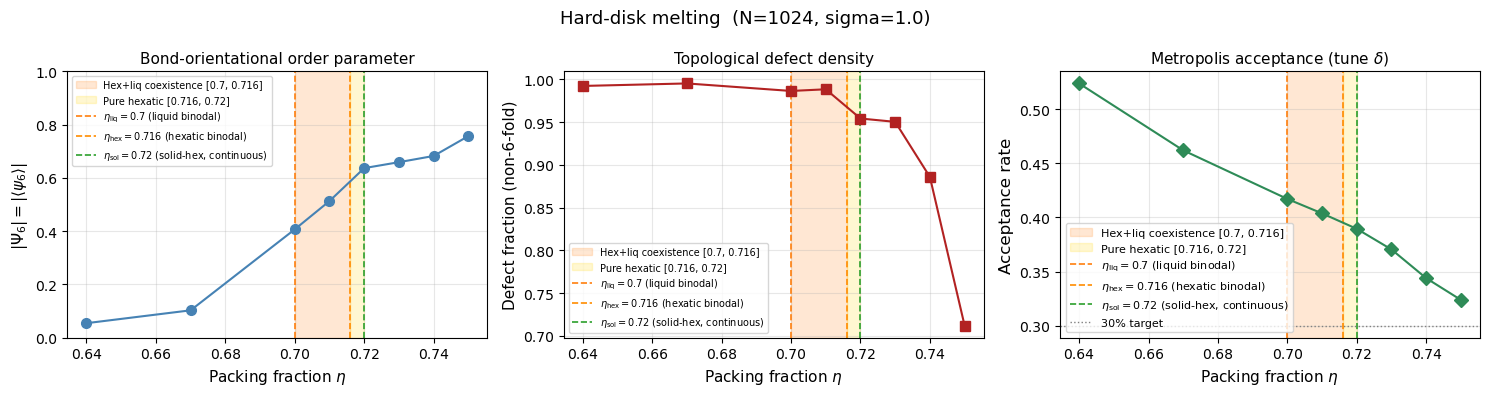

In [40]:
#----------------------------------------------------------------------
##  PLOT SCALAR OBSERVABLES vs PACKING FRACTION
##
##  Phase boundaries for hard disks (N -> infinity):
##    eta_liq  = 0.700  liquid binodal  (start of hex-liq coexistence)
##    eta_hex  = 0.716  hexatic binodal (end of hex-liq coexistence)
##    eta_sol  = 0.720  solid-hexatic   (continuous KTHNY transition)
##
##  The coexistence band [0.700, 0.716] is the first-order hex-liq
##  transition region — absent from the original KTHNY scenario.
#----------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Hard-disk melting  (N={N}, sigma={sigma})', fontsize=13)

# Boundaries (N -> infinity, Bernard & Krauth 2011; Kapfer & Krauth 2015)
eta_liq = 0.700   # liquid binodal: hex-liq coexistence starts
eta_hex = 0.716   # hexatic binodal: hex-liq coexistence ends; pure hexatic begins
eta_sol = 0.720   # solid-hexatic continuous (KTHNY) transition

for ax in axes:
    # First-order coexistence band
    ax.axvspan(eta_liq, eta_hex, alpha=0.18, color='C1',
               label=f'Hex+liq coexistence [{eta_liq}, {eta_hex}]')
    # Pure hexatic window
    ax.axvspan(eta_hex, eta_sol, alpha=0.18, color='gold',
               label=f'Pure hexatic [{eta_hex}, {eta_sol}]')
    # Transition lines
    ax.axvline(eta_liq, color='C1', linestyle='--', linewidth=1.2,
               label=rf'$\eta_{{\rm liq}}={eta_liq}$ (liquid binodal)')
    ax.axvline(eta_hex, color='darkorange', linestyle='--', linewidth=1.2,
               label=rf'$\eta_{{\rm hex}}={eta_hex}$ (hexatic binodal)')
    ax.axvline(eta_sol, color='C2', linestyle='--', linewidth=1.2,
               label=rf'$\eta_{{\rm sol}}={eta_sol}$ (solid-hex, continuous)')
    ax.set_xlabel(r'Packing fraction $\eta$', fontsize=11)
    ax.grid(alpha=0.3)

axes[0].plot(eta_vals, Psi6_avg, 'o-', ms=7, color='steelblue')
axes[0].set_ylabel(r'$|\Psi_6| = |\langle\psi_6\rangle|$', fontsize=11)
axes[0].set_title('Bond-orientational order parameter', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=7)

axes[1].plot(eta_vals, defect_frac, 's-', ms=7, color='firebrick')
axes[1].set_ylabel('Defect fraction (non-6-fold)', fontsize=11)
axes[1].set_title('Topological defect density', fontsize=11)
axes[1].legend(fontsize=7)

axes[2].plot(eta_vals, acc_rate, 'D-', ms=7, color='seagreen')
axes[2].axhline(0.3, color='gray', linestyle=':', linewidth=1, label='30% target')
axes[2].set_ylabel('Acceptance rate', fontsize=12)
axes[2].set_title(r'Metropolis acceptance (tune $\delta$)', fontsize=11)
axes[2].legend(fontsize=8)

plt.tight_layout()
fig_dir = 'figures/' + type_folder
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(fig_dir + '/observables_vs_eta.png', dpi=150)
plt.show()


Equilibrating coexistence point: 100%|██████████| 3000/3000 [00:00<00:00, 9678.01it/s]


Long run at eta=0.708 to collect |Psi6| time series...


Measuring: 100%|██████████| 20000/20000 [00:12<00:00, 1553.18it/s]


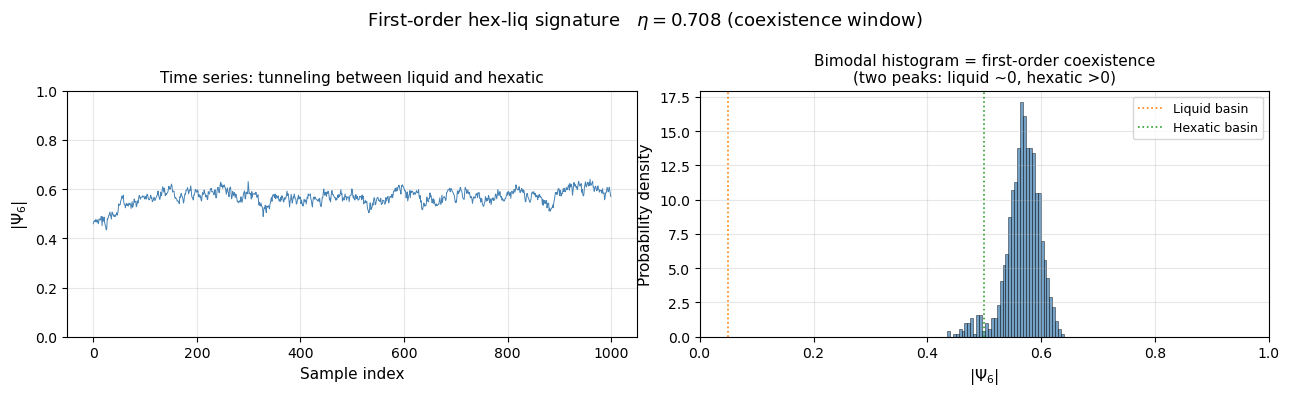

|Psi6| mean=0.567  std=0.031  -> likely unimodal (check eta is inside coexistence)


In [41]:
#----------------------------------------------------------------------
##  FIRST-ORDER SIGNATURE: BIMODAL |Psi6| DISTRIBUTION
##
##  Inside the coexistence window (eta ~ 0.705-0.710), the system
##  tunnels between hexatic and liquid domains.  A long run at fixed
##  eta inside the coexistence band should produce a BIMODAL histogram
##  of |Psi6|:
##    - Low peak  (~0)     : liquid regions
##    - High peak (~0.5-1) : hexatic regions
##
##  A unimodal histogram indicates a pure phase (either side of the
##  coexistence band).  This bimodality is absent in both the
##  continuous solid-hexatic transition and any truly second-order
##  hexatic-liquid transition, so it is the definitive finite-N
##  signature of the first-order character.
#----------------------------------------------------------------------

eta_coex  = 0.708         # target: inside the coexistence window
L_coex    = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta_coex))
nc_coex   = max(3, int(L_coex / sigma))
n_long    = 20000         # long run to capture tunneling events
sample_ev = 20            # sample |Psi6| every this many sweeps
Psi6_ts   = []

pos_cx, _ = init_positions(N, eta_coex, sigma)

# Brief equilibration
for _ in tqdm(range(3000), desc='Equilibrating coexistence point'):
    pos_cx, _ = mc_sweep(pos_cx, L_coex, sigma, delta, nc_coex, max_per_cell)

# Long measurement
print(f'Long run at eta={eta_coex} to collect |Psi6| time series...')
for step in tqdm(range(n_long), desc='Measuring'):
    pos_cx, _ = mc_sweep(pos_cx, L_coex, sigma, delta, nc_coex, max_per_cell)
    if step % sample_ev == 0:
        psi6_cx, _ = compute_psi6(pos_cx, L_coex)
        Psi6_ts.append(np.abs(np.mean(psi6_cx)))

Psi6_ts = np.array(Psi6_ts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(rf'First-order hex-liq signature   $\eta = {eta_coex}$ (coexistence window)', fontsize=13)

# Time series
ax1.plot(Psi6_ts, lw=0.7, color='steelblue')
ax1.set_xlabel('Sample index', fontsize=11)
ax1.set_ylabel(r'$|\Psi_6|$', fontsize=11)
ax1.set_title('Time series: tunneling between liquid and hexatic', fontsize=11)
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

# Histogram
ax2.hist(Psi6_ts, bins=40, density=True, color='steelblue', alpha=0.75, edgecolor='k', lw=0.4)
ax2.set_xlabel(r'$|\Psi_6|$', fontsize=11)
ax2.set_ylabel('Probability density', fontsize=11)
ax2.set_title('Bimodal histogram = first-order coexistence\n'
              '(two peaks: liquid ~0, hexatic >0)', fontsize=11)
ax2.set_xlim(0, 1)
ax2.grid(alpha=0.3)

# Mark the two expected peaks for guidance
ax2.axvline(0.05, color='C1', linestyle=':', lw=1.2, label='Liquid basin')
ax2.axvline(0.5,  color='C2', linestyle=':', lw=1.2, label='Hexatic basin')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(fig_dir + '/bimodal_psi6.png', dpi=150)
plt.show()

n_peaks = 'bimodal (two peaks -> first-order)' if Psi6_ts.std() > 0.15 else 'unimodal (check eta is inside coexistence)'
print(f'|Psi6| mean={Psi6_ts.mean():.3f}  std={Psi6_ts.std():.3f}  -> likely {n_peaks}')


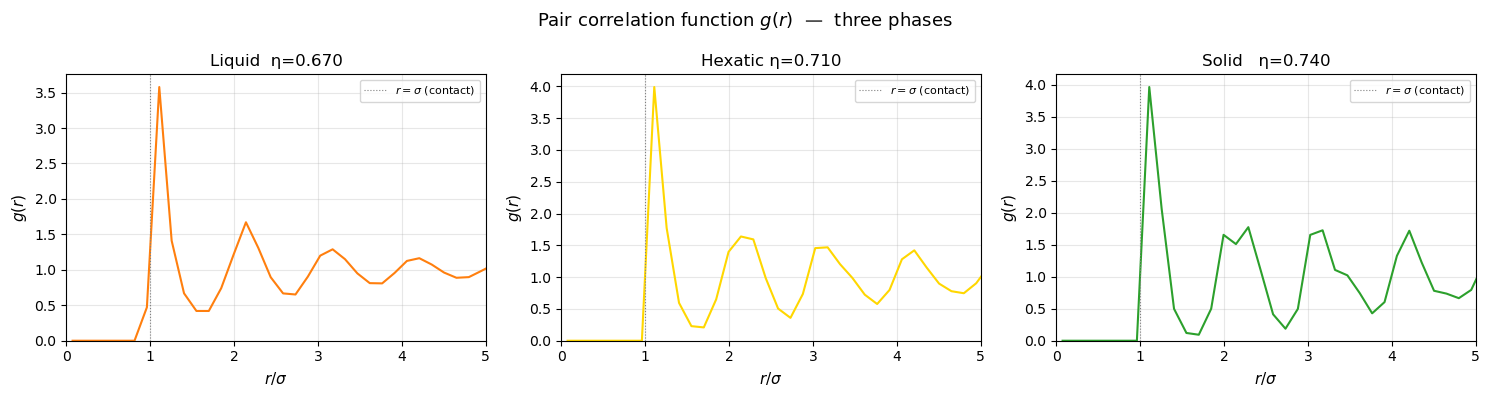

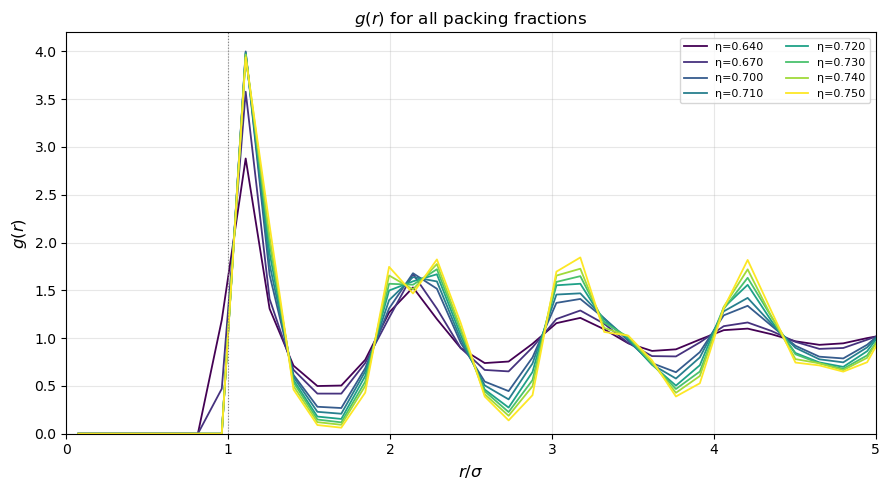

In [42]:
#----------------------------------------------------------------------
##  PAIR CORRELATION FUNCTION g(r) FOR THREE REPRESENTATIVE PHASES
#----------------------------------------------------------------------

# Pick one index from each expected phase
idx_liq = np.argmin(np.abs(eta_vals - 0.67))
idx_hex = np.argmin(np.abs(eta_vals - 0.71))
idx_sol = np.argmin(np.abs(eta_vals - 0.74))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(r'Pair correlation function $g(r)$  —  three phases', fontsize=13)

for ax, idx, label, color in [
    (axes[0], idx_liq, f'Liquid  η={eta_vals[idx_liq]:.3f}', 'C1'),
    (axes[1], idx_hex, f'Hexatic η={eta_vals[idx_hex]:.3f}', 'gold'),
    (axes[2], idx_sol, f'Solid   η={eta_vals[idx_sol]:.3f}', 'C2'),
]:
    ax.plot(r_vals / sigma, gr_all[idx], color=color, lw=1.5)
    ax.axvline(1.0, color='gray', linestyle=':', linewidth=0.8, label=r'$r=\sigma$ (contact)')
    ax.set_xlabel(r'$r / \sigma$', fontsize=11)
    ax.set_ylabel(r'$g(r)$', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(0, 5)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir + '/gr_phases.png', dpi=150)
plt.show()

# Overlay all eta on one plot
plt.figure(figsize=(9, 5))
cmap = plt.cm.viridis
for et, eta in enumerate(eta_vals):
    plt.plot(r_vals / sigma, gr_all[et], lw=1.3,
             color=cmap(et / (n_eta - 1)), label=f'η={eta:.3f}')
plt.axvline(1.0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel(r'$r / \sigma$', fontsize=12)
plt.ylabel(r'$g(r)$', fontsize=12)
plt.title(r'$g(r)$ for all packing fractions', fontsize=12)
plt.legend(fontsize=8, ncol=2)
plt.xlim(0, 5); plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir + '/gr_all.png', dpi=150)
plt.show()

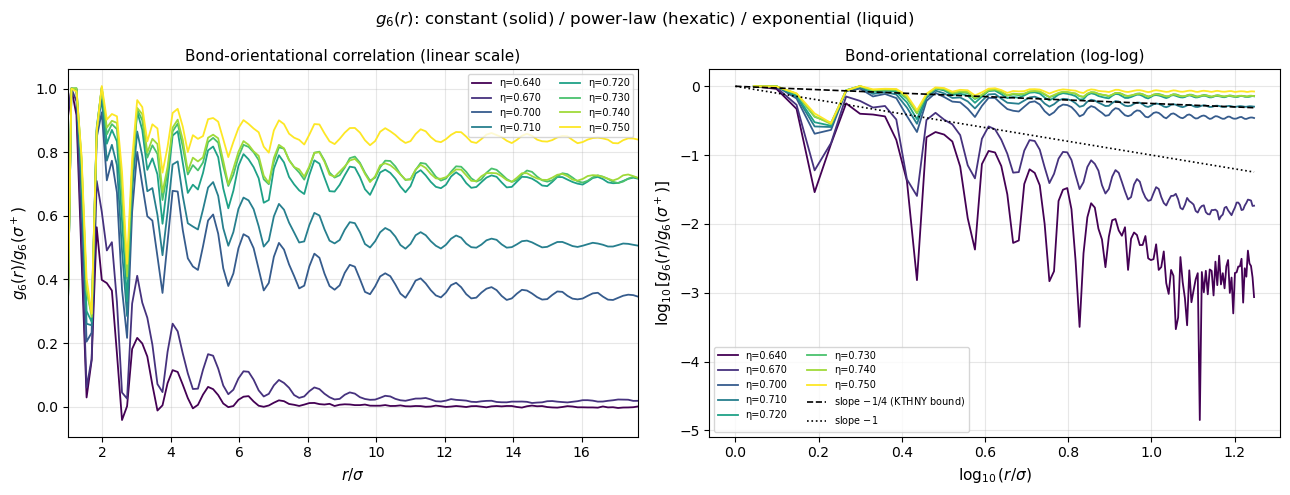

In [43]:
#----------------------------------------------------------------------
##  BOND-ORIENTATIONAL CORRELATION g_6(r)  —  KEY KTHNY DIAGNOSTIC
#
##  On a log-log plot:
##    Solid  : flat line  (long-range order)
##    Hexatic: straight line with slope > -1/4  (algebraic decay, quasi-LRO)
##    Liquid : curves down faster than power law  (exponential decay)
#----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Linear scale ----
ax = axes[0]
for et, eta in enumerate(eta_vals):
    g6 = g6r_all[et]
    # Normalise by first non-zero, non-contact bin
    k0 = np.argmax(r_vals > sigma)
    norm = g6[k0] if g6[k0] > 0 else 1.0
    ax.plot(r_vals / sigma, g6 / norm,
            lw=1.3, color=plt.cm.viridis(et / (n_eta - 1)), label=f'η={eta:.3f}')
ax.set_xlabel(r'$r / \sigma$', fontsize=11)
ax.set_ylabel(r'$g_6(r) / g_6(\sigma^+)$', fontsize=11)
ax.set_title('Bond-orientational correlation (linear scale)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
ax.set_xlim(1, r_vals[-1] / sigma)

# ---- Log-log scale ----
ax = axes[1]
r_plot = r_vals[r_vals > sigma]
for et, eta in enumerate(eta_vals):
    g6 = g6r_all[et][r_vals > sigma]
    k0 = 0
    norm = g6[k0] if g6[k0] > 0 else 1.0
    ax.plot(np.log10(r_plot / sigma), np.log10(np.abs(g6 / norm) + 1e-10),
            lw=1.3, color=plt.cm.viridis(et / (n_eta - 1)), label=f'η={eta:.3f}')

# Reference lines: slope -1/4 (KTHNY hexatic bound) and slope -1 (fast decay)
log_r = np.linspace(0, np.log10(r_vals[-1] / sigma), 50)
ax.plot(log_r, -0.25 * log_r, 'k--', lw=1.2, label=r'slope $-1/4$ (KTHNY bound)')
ax.plot(log_r, -1.0  * log_r, 'k:',  lw=1.2, label='slope $-1$')

ax.set_xlabel(r'$\log_{10}(r/\sigma)$', fontsize=11)
ax.set_ylabel(r'$\log_{10}[g_6(r)/g_6(\sigma^+)]$', fontsize=11)
ax.set_title('Bond-orientational correlation (log-log)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.suptitle(r'$g_6(r)$: constant (solid) / power-law (hexatic) / exponential (liquid)',
             fontsize=12)
plt.tight_layout()
plt.savefig(fig_dir + '/g6r_KTHNY.png', dpi=150)
plt.show()


--- Liquid  eta=0.670 ---


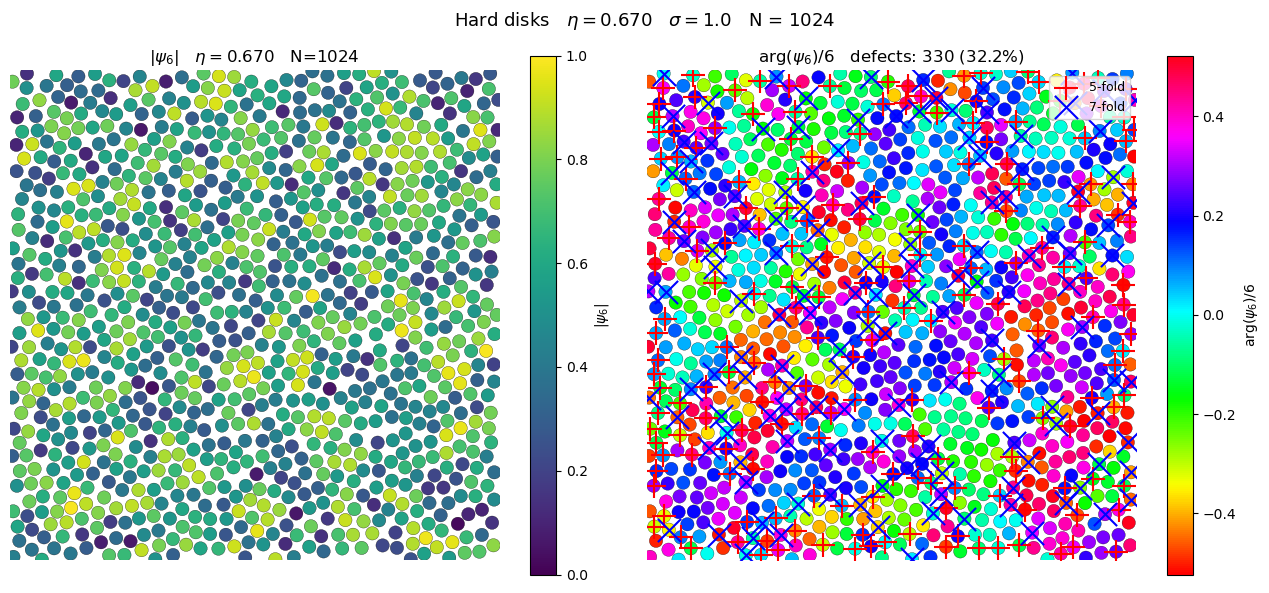


--- Hexatic  eta=0.710 ---


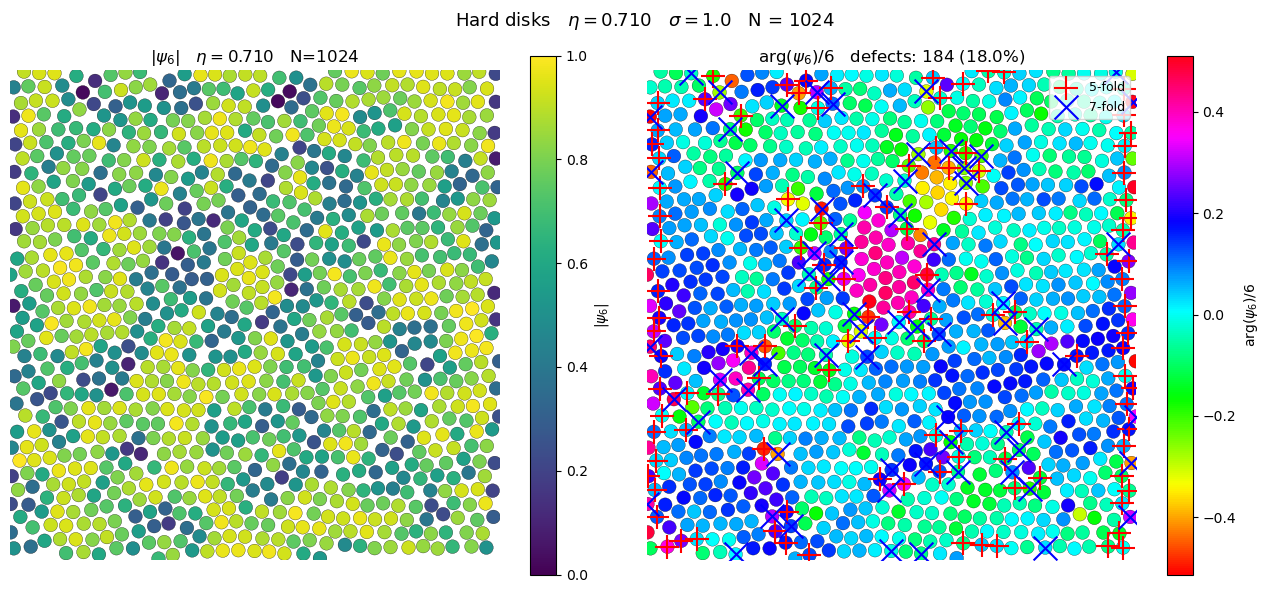


--- Solid  eta=0.740 ---


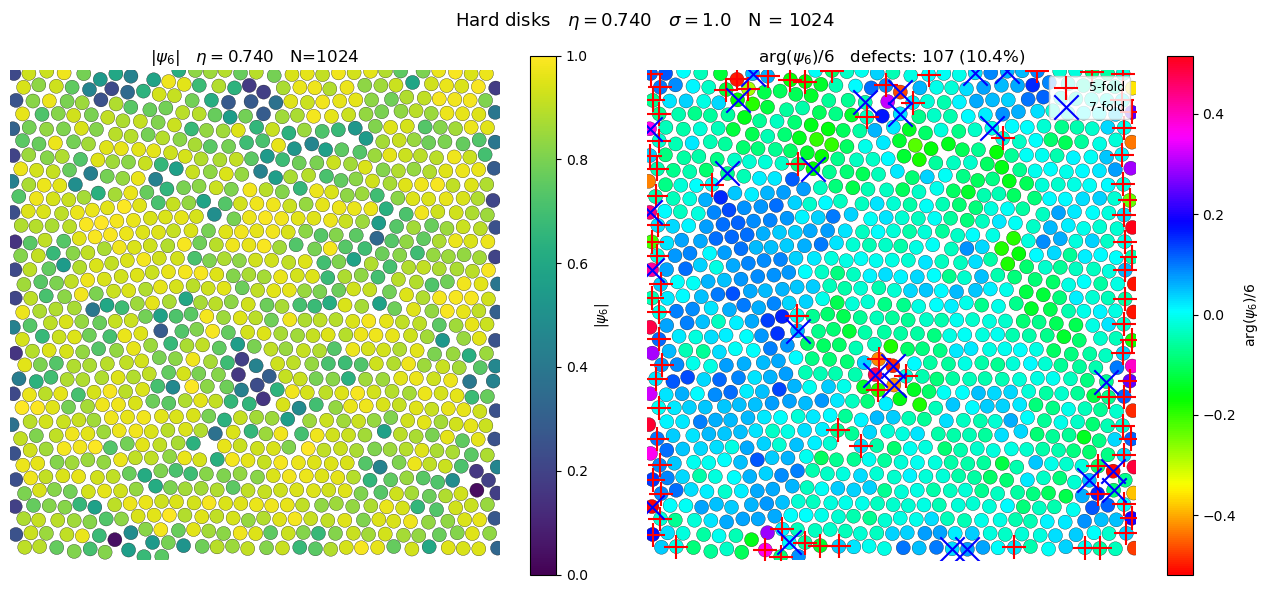

In [44]:
#----------------------------------------------------------------------
##  PARTICLE SNAPSHOTS FOR THREE REPRESENTATIVE PHASES
#----------------------------------------------------------------------

for idx, label in [(idx_liq, 'liquid'), (idx_hex, 'hexatic'), (idx_sol, 'solid')]:
    eta = eta_vals[idx]
    L_   = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta))
    print(f'\n--- {label.capitalize()}  eta={eta:.3f} ---')
    plot_snapshot(
        last_pos[idx], last_psi6[idx], last_ncoord[idx],
        L_, eta, sigma=sigma,
        folder=fig_dir
    )

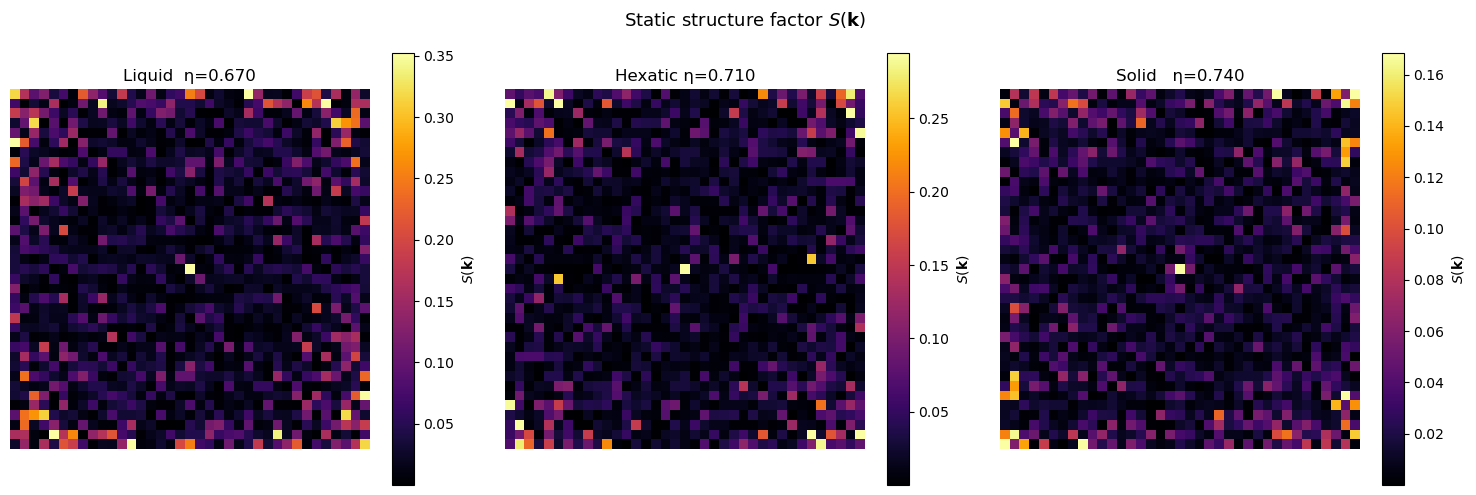

In [45]:
#----------------------------------------------------------------------
##  STRUCTURE FACTOR S(k)  —  Bragg peaks in solid, diffuse rings elsewhere
#----------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(r'Static structure factor $S(\mathbf{k})$', fontsize=13)

for ax, idx, label in [
    (axes[0], idx_liq, f'Liquid  η={eta_vals[idx_liq]:.3f}'),
    (axes[1], idx_hex, f'Hexatic η={eta_vals[idx_hex]:.3f}'),
    (axes[2], idx_sol, f'Solid   η={eta_vals[idx_sol]:.3f}'),
]:
    L_ = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta_vals[idx]))
    Sk = compute_Sk(last_pos[idx], L_, k_max_idx=18)
    # Clip the k=0 peak (self-term = N) for display
    Sk_display = np.clip(Sk, 0, np.percentile(Sk, 99.5))
    im = ax.imshow(Sk_display.T, origin='lower', cmap='inferno',
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, label=r'$S(\mathbf{k})$')
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig(fig_dir + '/Sk_phases.png', dpi=150)
plt.show()

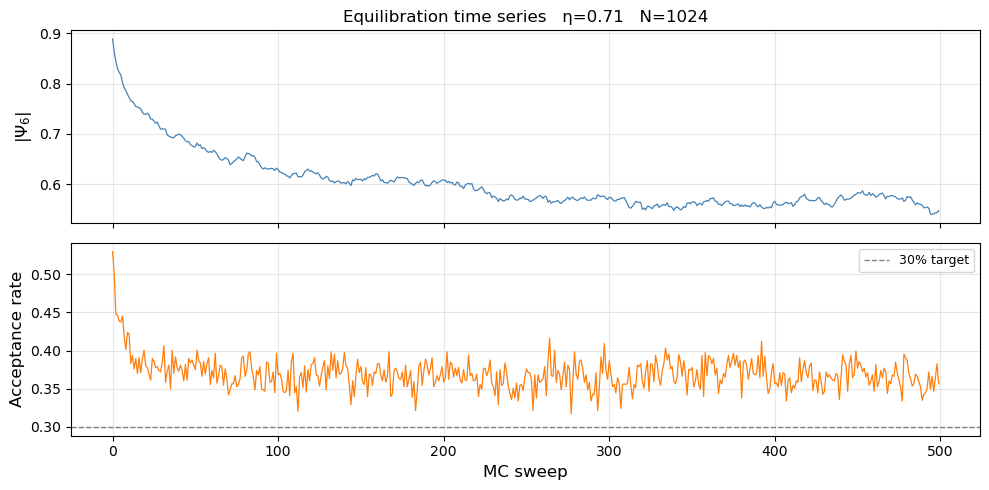

Mean acceptance rate: 0.37  (target 0.30-0.50; if outside this range adjust delta=0.1)


In [46]:
#----------------------------------------------------------------------
##  EQUILIBRATION CHECK  —  |Psi6| time series near the transitions
#----------------------------------------------------------------------

eta_chk = 0.71   # near the hexatic window
L_chk   = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta_chk))
nc_chk  = max(3, int(L_chk / sigma))
n_rec   = 500

pos_chk, _ = init_positions(N, eta_chk, sigma)
Psi6_ts    = np.zeros(n_rec)
acc_ts     = np.zeros(n_rec)

for step in range(n_rec):
    pos_chk, nacc = mc_sweep(pos_chk, L_chk, sigma, delta, nc_chk, max_per_cell)
    psi6_tmp, _   = compute_psi6(pos_chk, L_chk)
    Psi6_ts[step] = np.abs(np.mean(psi6_tmp))
    acc_ts[step]  = nacc / N

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(Psi6_ts, lw=0.9, color='steelblue')
ax1.set_ylabel(r'$|\Psi_6|$', fontsize=12)
ax1.set_title(f'Equilibration time series   η={eta_chk}   N={N}', fontsize=12)
ax1.grid(alpha=0.3)
ax2.plot(acc_ts, lw=0.9, color='C1')
ax2.axhline(0.3, color='gray', linestyle='--', linewidth=1, label='30% target')
ax2.set_ylabel('Acceptance rate', fontsize=12)
ax2.set_xlabel('MC sweep', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir + '/equilibration.png', dpi=120)
plt.show()

print(f'Mean acceptance rate: {acc_ts.mean():.2f}  '
      f'(target 0.30-0.50; if outside this range adjust delta={delta})')

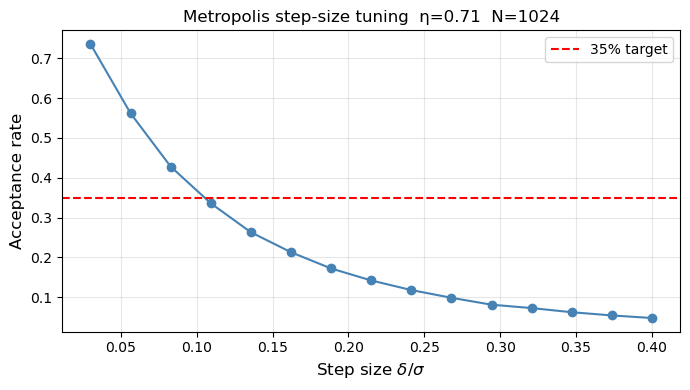

Delta giving ~35% acceptance at eta=0.71: delta = 0.109
Update  delta = 0.109  in the Parameters cell and re-run.


In [47]:
#----------------------------------------------------------------------
##  STEP-SIZE TUNING — find delta giving ~35% acceptance
##  Run this cell before the main loop if acceptance is far from target.
#----------------------------------------------------------------------

eta_tune    = 0.71
L_tune      = np.sqrt(N * np.pi * sigma**2 / (4.0 * eta_tune))
nc_tune     = max(3, int(L_tune / sigma))
delta_scan  = np.linspace(0.03, 0.40, 15)
acc_scan    = np.zeros(len(delta_scan))
n_tune      = 200

for d_idx, d in enumerate(delta_scan):
    pos_t, _ = init_positions(N, eta_tune, sigma)
    for _ in range(100):  # brief warmup
        pos_t, _ = mc_sweep(pos_t, L_tune, sigma, d, nc_tune, max_per_cell)
    total = 0
    for _ in range(n_tune):
        pos_t, nacc = mc_sweep(pos_t, L_tune, sigma, d, nc_tune, max_per_cell)
        total += nacc
    acc_scan[d_idx] = total / (n_tune * N)

plt.figure(figsize=(7, 4))
plt.plot(delta_scan, acc_scan, 'o-', ms=6, color='steelblue')
plt.axhline(0.35, color='red', linestyle='--', label='35% target')
plt.xlabel(r'Step size $\delta / \sigma$', fontsize=12)
plt.ylabel('Acceptance rate', fontsize=12)
plt.title(f'Metropolis step-size tuning  η={eta_tune}  N={N}', fontsize=12)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(fig_dir + '/delta_tuning.png', dpi=120)
plt.show()

best_delta = delta_scan[np.argmin(np.abs(acc_scan - 0.35))]
print(f'Delta giving ~35% acceptance at eta={eta_tune}: delta = {best_delta:.3f}')
print(f'Update  delta = {best_delta:.3f}  in the Parameters cell and re-run.')